# Customer Churn Prediction — Telecom Churn Dataset

**Goal:** Predict which customers are likely to cancel (churn) so the business can target them with retention offers before they leave.

**Success metric:** Recall on the churn class (missing a churner costs more than a false alarm — a false alarm just means an unnecessary retention offer).

**Data:** [Telecom Churn Dataset](https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets) (churn-bigml-80 for train/val, churn-bigml-20 held out untouched as the final test set).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Load data

In [2]:
train_df = pd.read_csv("churn-bigml-80-checkpoint.csv")
test_df = pd.read_csv("churn-bigml-20-checkpoint.csv")

print("train shape:", train_df.shape)
print("test shape (held out, untouched until final eval):", test_df.shape)
train_df.head()

train shape: (2666, 20)
test shape (held out, untouched until final eval): (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 2. Data inspection

No nulls, no duplicates (checked). Target is a boolean `Churn` column — map it to 0/1.

In [3]:
print("Nulls per column:\n", train_df.isnull().sum().sum())
print("Duplicate rows:", train_df.duplicated().sum())
train_df["Churn"] = train_df["Churn"].map({True: 1, False: 0})
test_df["Churn"] = test_df["Churn"].map({True: 1, False: 0})
train_df["Churn"].value_counts(normalize=True)

Nulls per column:
 0
Duplicate rows: 0


Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64

**Class imbalance:** ~14.5% churn / ~85.5% no-churn. This is why we score on **recall**, not accuracy — a model that predicts "no churn" for everyone would still score ~85% accuracy while catching zero at-risk customers.

## 3. Exploratory analysis

In [4]:
corr_acct_len = train_df[["Account length", "Churn"]].corr().iloc[0, 1]
print(f"Account length vs Churn correlation: {corr_acct_len:.4f}  -> ~0, not predictive, drop it")

churn_by_csc = train_df.groupby("Customer service calls")["Churn"].mean()
print("\nChurn rate by customer service calls:\n", churn_by_csc)

Account length vs Churn correlation: 0.0177  -> ~0, not predictive, drop it

Churn rate by customer service calls:
 Customer service calls
0    0.142342
1    0.104762
2    0.101974
3    0.106322
4    0.481203
5    0.591837
6    0.588235
7    0.625000
8    1.000000
9    1.000000
Name: Churn, dtype: float64


More customer service calls -> sharply higher churn. International plan holders churn roughly 4x more often than those without one. These become two of the strongest predictive signals below.

## 4. Drop leaky / low-signal columns

In [5]:
# Total day/eve/night/intl "charge" columns are a near-perfect linear function
# of the matching "minutes" columns (charge = rate * minutes) -> redundant, drop.
# State / Area code -> too high-cardinality, no real business signal.
# Account length -> ~0 correlation with churn (confirmed above).
charge_cols = ["Total day charge", "Total eve charge", "Total night charge", "Total intl charge"]
drop_cols = ["State", "Area code", "Account length"] + charge_cols

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)
train_df.head()

,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


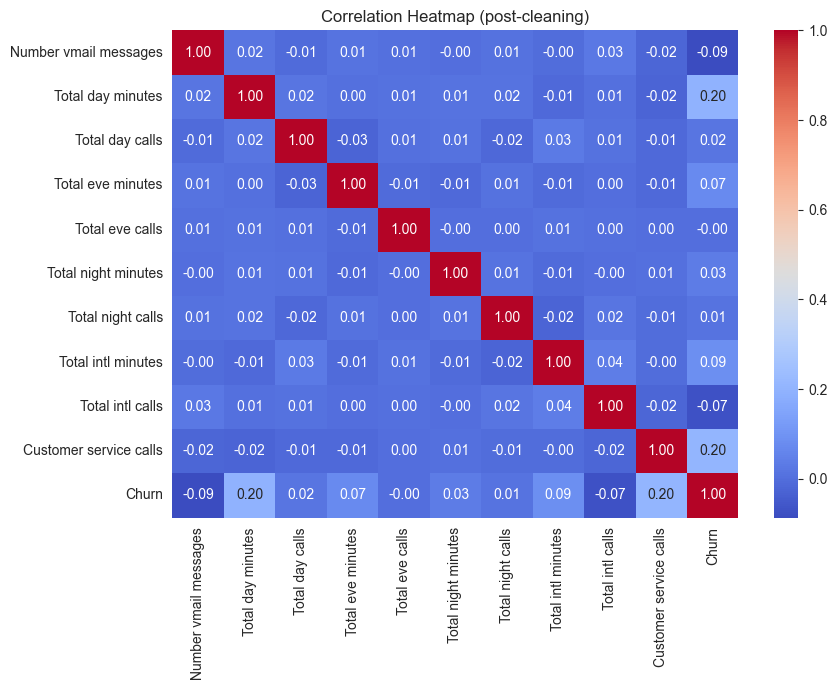

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (post-cleaning)")
plt.tight_layout()
plt.show()

## 5. Train / validation split

`test_df` (churn-bigml-20) stays completely untouched until the final evaluation at the end — this is the credibility check.

In [7]:
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test (holdout):", X_test.shape)

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()
print("categorical:", categorical_cols)
print("numerical:", numerical_cols)

X_train: (2132, 12) X_val: (534, 12) X_test (holdout): (667, 12)
categorical: ['International plan', 'Voice mail plan']
numerical: ['Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']


## 6. Baseline: Logistic Regression

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ]
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)),
])

lr_pipeline.fit(X_train, y_train)
lr_val_pred = lr_pipeline.predict(X_val)
print(classification_report(y_val, lr_val_pred))

              precision    recall  f1-score   support

           0       0.93      0.76      0.83       456
           1       0.32      0.65      0.43        78

    accuracy                           0.74       534
   macro avg       0.62      0.71      0.63       534
weighted avg       0.84      0.74      0.78       534



In [9]:
ohe_names = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(ohe_names)
lr_coefs = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": lr_pipeline.named_steps["model"].coef_[0]
}).sort_values("Coefficient", ascending=False)
lr_coefs

,Feature,Coefficient
10,International plan_Yes,2.546347
9,Customer service calls,0.832051
1,Total day minutes,0.727792
3,Total eve minutes,0.275237
7,Total intl minutes,0.249093
5,Total night minutes,0.212496
0,Number vmail messages,0.092050
2,Total day calls,0.051812
4,Total eve calls,0.017325
6,Total night calls,0.011909


Logistic Regression recall (65%) beats its own precision badly — it over-flags. Useful as a baseline and for readable coefficients, but Random Forest below does much better on both.

## 7. Random Forest

In [10]:
# NOTE: unlike Logistic Regression, RandomForestClassifier cannot take raw
# "Yes"/"No" string columns — they must go through the same kind of
# ColumnTransformer/OneHotEncoder before fitting.
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ]
)

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)),
])

rf_pipeline.fit(X_train, y_train)
rf_val_pred = rf_pipeline.predict(X_val)
print(classification_report(y_val, rf_val_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       456
           1       0.98      0.64      0.78        78

    accuracy                           0.95       534
   macro avg       0.96      0.82      0.87       534
weighted avg       0.95      0.95      0.94       534



## 8. Hyperparameter tuning (GridSearchCV, scoring = recall)

In [11]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)

best_rf_pipeline = grid_search.best_estimator_
best_val_pred = best_rf_pipeline.predict(X_val)
print(classification_report(y_val, best_val_pred))

Best Params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       456
           1       0.92      0.74      0.82        78

    accuracy                           0.95       534
   macro avg       0.94      0.87      0.90       534
weighted avg       0.95      0.95      0.95       534



## 9. Final evaluation — untouched holdout test set

This is the number that actually matters for a portfolio: performance on `churn-bigml-20`, which the model has never seen in training or tuning.

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       572
           1       0.88      0.79      0.83        95

    accuracy                           0.96       667
   macro avg       0.92      0.89      0.90       667
weighted avg       0.95      0.96      0.95       667

ROC-AUC: 0.9244387191755612


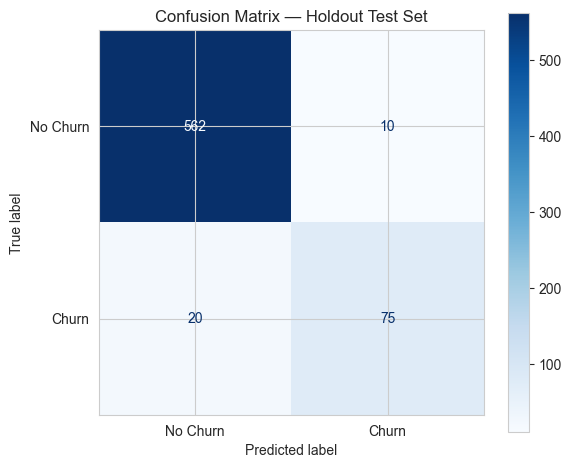

In [12]:
test_pred = best_rf_pipeline.predict(X_test)
test_proba = best_rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix — Holdout Test Set")
plt.tight_layout()
plt.show()

**On genuinely unseen customers, the model catches 79% of churners at 88% precision (ROC-AUC 0.92).** Of 95 real churners in the holdout set, it flags 75 and misses 20 — those 20 are the ones a retention team would want the SHAP dashboard to help catch next.

## 10. Feature importance

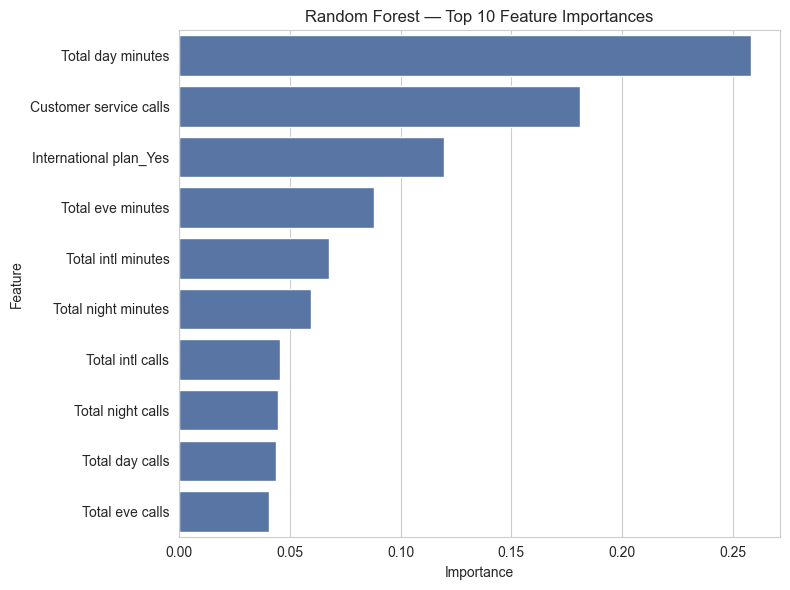

,Feature,Importance
1,Total day minutes,0.258420
9,Customer service calls,0.181057
10,International plan_Yes,0.119516
3,Total eve minutes,0.087930
7,Total intl minutes,0.067703
5,Total night minutes,0.059703
8,Total intl calls,0.045642
6,Total night calls,0.044721
2,Total day calls,0.043704
4,Total eve calls,0.040734


In [13]:
rf_ohe_names = best_rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
rf_feature_names = numerical_cols + list(rf_ohe_names)
importances = best_rf_pipeline.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"Feature": rf_feature_names, "Importance": importances}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_df.head(10), x="Importance", y="Feature", color="#4C72B0")
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout()
plt.show()
fi_df.head(10)

## 11. Save the model



In [15]:
joblib.dump(best_rf_pipeline, "model.pkl")
fi_df.to_csv("feature_importance.csv", index=False)
print("Saved model.pkl")

Saved model.pkl
